# **DATA PREPROCESSING TABULAR**

In [1]:
!git clone https://github.com/quanpro147/HCMUS-DataMining-Prj1.git

fatal: destination path 'HCMUS-DataMining-Prj1' already exists and is not an empty directory.


In [2]:
%cd HCMUS-DataMining-Prj1

/content/HCMUS-DataMining-Prj1


---

## **1. Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    QuantileTransformer
)

## **2. Load Raw Data For Preprocessing**

Dựa trên những phát hiện quan trọng thu được ở bước khám phá dữ liệu (EDA) — giai đoạn tiền xử lý được triển khai nhằm chuẩn hóa cấu trúc dữ liệu, đảm bảo mỗi biến phản ánh đúng bản chất định tính hoặc định lượng của nó.

Khác với các bộ dữ liệu đã được làm sạch sẵn, dữ liệu điều tra dân số thực tế thường chứa các ký tự dị thường (`?`). Bước khởi tạo này sẽ nạp dữ liệu và ép kiểu các ký tự lỗi về chuẩn `np.nan` của thư viện Pandas.

In [4]:
adult_path = "data/raw/tabular/adult.csv"
df_adult = pd.read_csv(adult_path)
df_adult = df_adult.replace(regex=r'^\s*\?\s*$', value=np.nan)

num_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
for col in num_cols:
    if col in df_adult.columns:
        df_adult[col] = pd.to_numeric(df_adult[col], errors='coerce')

Dữ liệu được đọc từ tệp `adult.csv` thành công và được khởi tạo dưới dạng cấu trúc dữ liệu bảng (tabular), lưu trữ trong biến DataFrame `df_adult`.

## **3. Controlled Missing Value Imputation**

**Mục tiêu:** Thay vì áp dụng mù quáng một thuật toán điền khuyết, nhóm tiến hành đánh giá định lượng hiệu quả của 5 chiến lược thông qua môi trường mô phỏng (simulation). Cụ thể, nhóm sẽ giả lập mất mát dữ liệu (MCAR) trên một biến số học hoàn chỉnh, sau đó dùng các thuật toán để nội suy và tính toán sai số RMSE so với Ground Truth.

### **3.1 Theoretical Foundation & Mathematical Formulas**

Trước khi thực thi, việc thấu hiểu nền tảng toán học và giả định của từng thuật toán là bắt buộc để đánh giá rủi ro sai lệch (bias) mà chúng có thể mang lại.

#### 1. Arithmetic Mean Imputation

* **Lý thuyết:** Đây là kỹ thuật điền khuyết đơn giản nhất dành cho dữ liệu liên tục. Nó sử dụng thước đo xu hướng tập trung, giả định rằng giá trị trung bình là giá trị có khả năng xuất hiện cao nhất đối với một quan sát lấy ngẫu nhiên từ phân phối chuẩn (Gaussian). Tuy nhiên, nó cực kỳ nhạy cảm với ngoại lai, làm giảm nhân tạo phương sai của biến và thu hẹp khoảng tin cậy.
* **Toán học:** Giá trị trung bình mẫu $\bar{x}$ được tính bằng:
  $$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

#### 2. Median Imputation

* **Lý thuyết:** Một giải pháp thay thế mạnh mẽ cho phương pháp trung bình, đặc biệt khi dữ liệu có độ lệch (skewness) cao hoặc chứa ngoại lai ngoại lai (như biến `capital.gain` trong tập dữ liệu này). Tuy nhiên, nó vẫn làm biến dạng phân phối do tạo ra một spike nhân tạo tại vùng trung tâm.
* **Toán học:** Dữ liệu quan sát được sắp xếp tăng dần: $x_{(1)}, x_{(2)}, \dots, x_{(n)}$.
  * Nếu $n$ lẻ: Trung vị là $x_{(\frac{n+1}{2})}$.
  * Nếu $n$ chẵn: Trung vị là $\frac{x_{(\frac{n}{2})} + x_{(\frac{n}{2} + 1)}}{2}$.

#### 3. Mode Imputation

* **Lý thuyết:** Giá trị xuất hiện với tần suất cao nhất. Chủ yếu dùng cho biến phân loại (Categorical). Mặc dù đơn giản, phương pháp này thất bại nếu phân phối đa đỉnh (multimodal) và bỏ qua hoàn toàn mối tương quan giữa các đặc trưng.
* **Toán học:** Là giá trị $x_i$ cực đại hóa hàm tần suất $f(x)$.

#### 4. k-Nearest Neighbors (k-NN) Imputation

* **Lý thuyết:** k-NN là thuật toán lazy learning phi tham số. Thay vì dùng một hằng số toàn cục, nó nội suy bằng cách tìm $k$ quan sát hoàn chỉnh giống nhất (hàng xóm) trong không gian đặc trưng.
  * $k=3$: Bám sát mẫu cục bộ, rủi ro quá khớp (overfitting) với nhiễu.
  * $k=5$: Trạng thái cân bằng tối ưu, lọc được nhiễu nhưng vẫn giữ được cấu trúc.
  * $k=10$: Rủi ro trơn hóa quá mức (underfitting), dần hội tụ về trung bình toàn cục.
* **Toán học:** Tính khoảng cách (ví dụ: Euclidean) giữa các điểm dữ liệu:
  $$d(a, b) = \sqrt{\sum_{i=1}^{m} (a_i - b_i)^2}$$

#### 5. Multiple Imputation by Chained Equations (MICE)

* **Lý thuyết:** Còn gọi là Fully Conditional Specification (FCS). Hoạt động dưới giả định MAR, MICE lập mô hình từng biến bị khuyết như một hàm của các biến còn lại thông qua một chuỗi các phương trình hồi quy. MICE bảo toàn hình dáng phân phối và tính đa đỉnh (multimodality) xuất sắc.
* **Toán học:** Mô hình hồi quy cơ bản cho biến liên tục:
  $$x_{j, obs} = \beta_0 + \mathbf{X}_{-j, obs} \boldsymbol{\beta} + \epsilon_j, \quad \epsilon_j \sim N(0, \sigma^2)$$
  *Luật kết hợp Rubin (Rubin's Rules):* Tổng hợp từ $H$ bộ dữ liệu với phương sai tổng cộng $T$:
  $$T = \bar{V}_H + \left(1 + \frac{1}{H}\right) B_H$$

### **3.2 MCAR Injection**

Nhóm lựa chọn thuộc tính `age` (Tuổi) làm đối tượng thử nghiệm vì cột này nguyên bản không có giá trị khuyết (hoàn hảo để làm Ground Truth) và có tương quan với nhiều biến kinh tế khác. Nhóm sẽ chủ động xóa ngẫu nhiên 10% (MCAR) dữ liệu tại cột này.

In [5]:
# Define target and ground truth
target_col = 'age'
ground_truth = df_adult[target_col].copy()

# Simulate missing data (10%)
df_sim = df_adult.copy()
np.random.seed(42)
drop_ratio = 0.10
n_rows = len(df_sim)
mask_missing = np.random.rand(n_rows) < drop_ratio
df_sim.loc[mask_missing, target_col] = np.nan

print("\tMISSING DATA SIMULATION")
print(f"Missing values introduced: {mask_missing.sum():,}")
print(f"Missing ratio            : {(mask_missing.sum() / n_rows) * 100:.2f}%")

missing_indices = df_sim[df_sim[target_col].isna()].index

	MISSING DATA SIMULATION
Missing values introduced: 3,292
Missing ratio            : 10.11%


### **3.3 Implementation & Evaluation**

Nhóm tiến hành cài đặt 5 chiến lược (kèm các biến thể của k-NN) và đo lường *RMSE (Root Mean Square Error)*. Chỉ số RMSE càng thấp chứng tỏ giá trị nội suy càng bám sát với dữ liệu thực tế (Ground Truth) đã bị xóa.

In [6]:
# Prepare numerical data
df_num_sim = df_sim[num_cols].copy()
true_values = ground_truth.loc[missing_indices]
def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Evaluate imputation strategies
results = {}

# Mean
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Mean'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# Median
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Median'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# Mode
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Mode'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# k-NN (k = 3, 5, 10)
for k in [3, 5, 10]:
    imputer = KNNImputer(n_neighbors=k)
    df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
    results[f'KNN (k={k})'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# MICE
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['MICE'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

df_results = pd.DataFrame(list(results.items()), columns=['Strategy', 'RMSE'])
df_results = df_results.sort_values(by='RMSE').reset_index(drop=True)

print("\tIMPUTATION PERFORMANCE COMPARISON (RMSE)")
display(df_results.style.format({"RMSE": "{:.4f}"}).background_gradient(cmap='RdYlGn_r', subset=['RMSE']))

	IMPUTATION PERFORMANCE COMPARISON (RMSE)


,Strategy,RMSE
0,MICE,13.6168
1,Mean,13.7441
2,Median,13.8629
3,KNN (k=10),13.9142
4,Mode,14.0301
5,KNN (k=5),14.1470
6,KNN (k=3),14.4262


### **3.4 Performance Comparison & Strategy Selection**

Dựa trên cơ sở lý thuyết và kết quả thực nghiệm RMSE với 10.11% dữ liệu khuyết nhân tạo, nhóm thiết lập bảng đối chiếu chiến lược:

| Chiến lược | Giả định | Bảo toàn phân phối | Bảo toàn tương quan | Chi phí tính toán |
| :--- | :--- | :--- | :--- | :--- |
| **Mean** | MCAR, Normal | Rất thấp (Tạo chóp nhọn) | Kém | Cực thấp |
| **Median** | MCAR, Skewed | Thấp | Kém | Cực thấp |
| **Mode** | MCAR | Thấp | Kém | Cực thấp |
| **k-NN** | MAR / MCAR | Cao (dùng mẫu cục bộ) | Trung bình - Cao | Cao |
| **MICE** | MAR | Rất Cao | Cao (hồi quy đa biến)| Khá Cao |

**The Best Strategy: Hybrid Imputation Strategy**

**Lý giải:**
Đối với các ứng dụng khoa học dữ liệu, nhóm áp dụng chiến lược điền khuyết linh hoạt dựa trên bản chất kiểu dữ liệu (data Type):

**1. Numerical Data:** Kết quả mô phỏng RMSE chứng minh MICE là thuật toán nội suy ưu việt nhất cho biến định lượng (RMSE = 13.61).
* *Empirical Evidence:* Các phương pháp gán hằng số toàn cục (Mean/Median) vượt trội hơn k-NN do k-NN bị nhiễu bởi khoảng cách Euclidean chưa chuẩn hóa (Curse of Dimensionality). Tuy nhiên, MICE đánh bại tất cả nhờ khai thác triệt để mối quan hệ đa biến.
* *Handling of Uncertainty:* MICE lồng ghép phương sai giữa các lần điền khuyết (between-imputation variance), ngăn chặn hiện tượng mô hình bị *overconfident* và bảo vệ khoảng tin cậy.
* *Distributional Fidelity:* MICE tái tạo lại phân phối mà không tạo chóp nhọn nhân tạo như Mean/Median.

**2. Categorical Data:** Mặc dù MICE rất mạnh mẽ, nhưng các thuộc tính bị khuyết thực tế trong tập Adult Census (`workclass`, `occupation`, `native.country`) đều là *biến định danh (Nominal Categorical)*. Việc ép MICE chạy trên các biến này đòi hỏi phải mã hóa thành số, vô tình tạo ra các mối quan hệ thứ tự giả tạo và làm sai lệch ý nghĩa xã hội học của dữ liệu.

**3. Mode Imputation:** Để ngăn chặn rủi ro toán học trên, chiến lược an toàn và chuẩn mực nhất cho nhóm biến phân loại của bộ Adult là sử dụng *Mode Imputation*. Phương pháp này lấp đầy các ô trống bằng hạng mục phổ biến nhất, giúp bảo toàn nguyên vẹn tính danh xưng của dữ liệu phân loại mà không làm nhiễu không gian đặc trưng.

**Next Step:** Trong quy trình pipeline chính thức, nhóm sẽ thực thi `SimpleImputer(strategy='most_frequent')` để làm sạch triệt để các giá trị `NaN` tại 3 cột Categorical này trước khi chuyển sang giai đoạn Phát hiện ngoại lai (Outlier Detection).

### **3.5 Apply Imputation To Original Data**

In [7]:
missing_before = df_adult.isna().sum()
missing_before = missing_before[missing_before > 0]
print("\tMISSING VALUE SUMMARY (BEFORE IMPUTATION)")
if not missing_before.empty:
    print(missing_before)
else:
    print("No missing values detected.")

# Define categorical columns with missing values
categorical_cols = ['workclass', 'occupation', 'native.country']

# Apply Mode imputation
imputer = SimpleImputer(strategy='most_frequent')
df_adult[categorical_cols] = imputer.fit_transform(df_adult[categorical_cols])

total_missing_after = df_adult.isna().sum().sum()
print("\tMISSING VALUE SUMMARY (AFTER IMPUTATION)")
print(f"Total remaining missing values: {total_missing_after:,}")
if total_missing_after == 0:
    print("Status: Dataset is now fully cleaned (no missing values remain).")
else:
    print("Warning: Some missing values still exist. Further inspection required.")

	MISSING VALUE SUMMARY (BEFORE IMPUTATION)
workclass         1836
occupation        1843
native.country     583
dtype: int64
	MISSING VALUE SUMMARY (AFTER IMPUTATION)
Total remaining missing values: 0
Status: Dataset is now fully cleaned (no missing values remain).


## **4. Outlier Detection and Treatment**

**Mục tiêu:** Xây dựng cơ chế ensemble để xác định các quan sát bất thường trong các biến liên tục. Đánh giá sự chồng chéo giữa các thuật toán và đo lường tác động của việc loại bỏ ngoại lai đến hình dáng phân phối bằng kiểm định thống kê.

### **4.1 Theoretical Foundation & Mathematical Formulas**

#### 1. Interquartile Range (IQR) and Z-Score

* **IQR (Interquartile Range):** Là phương pháp phi tham số, tập trung vào 50% dữ liệu ở giữa, giúp nó cực kỳ bền vững trước các giá trị ngoại lai.
  * *Công thức:* $IQR = Q_3 - Q_1$.
  * *Ngưỡng cảnh báo:*
      * $\text{Lower} = Q_1 - 1.5 \times IQR$
      * $\text{Upper} = Q_3 + 1.5 \times IQR$.
* **Z-Score:** Phương pháp tham số giả định dữ liệu có phân phối chuẩn. Định lượng khoảng cách từ một điểm đến trung bình mẫu tính bằng độ lệch chuẩn. Rất dễ bị hiện tượng "che khuất" (masking) do ngoại lai làm phình to phương sai.
  * *Công thức:* $Z = \frac{x - \mu}{\sigma}$. Các quan sát có $|Z| > 3$ được xem là ngoại lai.
  * *Độ chồng chéo:* IQR và Z-score thường có độ tương đồng Jaccard rất cao ($>0.8$) trong các phân phối chuẩn, nhưng Z-score dễ thất bại ở dữ liệu đa chiều.

#### 2. Isolation Forest (iForest)

* **Lý thuyết:** Thuật toán Ensemble cô lập các điểm dị thường bằng cách phân chia ngẫu nhiên không gian dữ liệu. Ngoại lai thường nằm ở các vùng thưa thớt, do đó chúng sẽ bị cô lập nhanh chóng với số rẽ nhánh ít hơn, tạo ra chiều dài đường đi ngắn hơn trong cây.
* **Công thức (Điểm dị thường):**
  $$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
  *(Trong đó $E(h(x))$ là chiều dài đường đi trung bình, và $c(n)$ là chiều dài kỳ vọng của cây tìm kiếm nhị phân).* Điểm $s \approx 1$ ám chỉ ngoại lai.
* **Tác động của `contamination` (Tỉ lệ nhiễu):**
  * `0.01`: Cực kỳ thận trọng, chỉ bắt các điểm dị biệt rõ rệt (độ chính xác cao, Recall thấp).
  * `0.05`: Trạng thái tiêu chuẩn, cân bằng giữa rủi ro bỏ sót và báo động giả.
  * `0.10`: Aggressive, bắt các ngoại lai vi tế nhưng dễ gán nhãn sai vùng biên cụm.

#### 3. Local Outlier Factor (LOF)

* **Lý thuyết:** Phương pháp không giám sát dựa trên mật độ. Nó đánh giá mức độ cô lập của một điểm so với các "hàng xóm" lân cận. Rất mạnh trong việc tìm ngoại lai cục bộ ở các tập dữ liệu có mật độ phân tán không đồng đều.
* **Công thức toán học:**
  * *Khoảng cách khả đạt:* $\text{reach-dist}_k(p, o) = \max\{d_k(o), \text{dist}(p, o)\}$
  * *Mật độ khả đạt cục bộ (LRD):* $lrd_k(p) = \frac{|N_k(p)|}{\sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}$
  * *Chỉ số LOF:* $LOF_k(p) = \frac{\sum_{o \in N_k(p)} \frac{lrd_k(o)}{lrd_k(p)}}{|N_k(p)|}$. (Điểm số $\gg 1$ cảnh báo ngoại lai).
* **Tác động của `n_neighbors` ($k$):**
  * `10`: Nhạy cảm, tập trung vào vi cấu trúc cục bộ.
  * `20`: Mức "sweet spot", cân bằng và ổn định (độ chính xác thường $\sim 75-84\%$).
  * `50`: Tầm nhìn toàn cục (Global), làm mờ chi tiết, dễ mất đi năng lực phát hiện ngoại lai cục bộ.

#### 4. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

* **Lý thuyết:** Nhận diện các vùng không gian mật độ cao thông qua bán kính $\epsilon$ và số điểm tối thiểu $MinPts$. Các điểm không thuộc bất kỳ cụm nào được gán nhãn là nhiễu (Noise / Outlier).
* **Hiện tượng "Outlier Cluster Cluster":** Nếu các điểm dị thường nằm gần nhau thỏa mãn $\epsilon$ và $MinPts$, chúng sẽ tự tạo thành một cụm riêng biệt thay vì bị coi là nhiễu, làm giảm khả năng nhận diện. Cần tinh chỉnh tham số cẩn thận.

#### 5. Kolmogorov-Smirnov (KS) Test

* **Lý thuyết:** Kiểm định phi tham số so sánh hàm phân phối tích lũy thực nghiệm (CDFs) trước và sau khi xử lý ngoại lai để đánh giá xem sự can thiệp có làm bóp méo bản chất dữ liệu hay không.
* **Công thức thống kê $D$:**
  $$D_{n,m} = \sup_x |F_1(x) - F_2(x)|$$
* **Biện luận:** Việc xóa bỏ thường trả về P-value $< 0.05$ (làm biến dạng phân phối). Trong khi cắt tỉa (Winsorization/Capping) thường bảo toàn phân phối tốt hơn (P-value $> 0.05$).

### **4.2 Algorithm Implementations & Detection Rates**

Nhóm tiến hành cài đặt 4 chiến lược phát hiện ngoại lai trên nhóm biến định lượng. Để đảm bảo các thuật toán dựa trên mật độ và khoảng cách (LOF, DBSCAN) hoạt động chính xác và không bị bóp méo bởi sự chênh lệch thang đo (ví dụ: `age` vs `capital.gain`), dữ liệu sẽ được chuẩn hóa tạm thời (`StandardScaler`) trước khi đưa vào thuật toán.

**Lưu ý kỹ thuật:** Cả LOF và DBSCAN đều phải dò tìm lân cận (Nearest Neighbor Search). Phương pháp brute-force yêu cầu lưu trữ ma trận khoảng cách $N \times N$, đẩy độ phức tạp không gian lên $O(n^2)$.

**Optimization Strategy:**
1. **Data Downcasting:** Chuyển toàn bộ mảng dữ liệu từ `float64` mặc định xuống `float32`, lập tức giảm 50% dung lượng RAM tiêu thụ.
2. **Spatial Indexing:** Bắt buộc sử dụng cấu trúc `algorithm='kd_tree'` thay vì tính ma trận toàn cục. Cấu trúc cây giúp giảm độ phức tạp truy vấn xuống $O(n \log n)$ thay vì tính toán ma trận khoảng cách đối xứng toàn cục.
3. **Leaf Size:** Cấu hình `leaf_size=50` (thay vì mặc định 30). Kích thước lá lớn hơn giúp giảm số lượng node trên cây, tiết kiệm dung lượng lưu trữ kiến trúc cây trong RAM.
4. **Disable Multiprocessing:** Đặt `n_jobs=1` cho LOF và DBSCAN. Đa luồng (`n_jobs=-1`) trong Scikit-learn sẽ fork ra nhiều tiến trình con, mỗi tiến trình sao chép một bản ma trận khoảng cách, là nguyên nhân chính gây tràn RAM đột ngột.

In [8]:
# Feature selection
outlier_features = [
    'age', 'fnlwgt', 'education.num',
    'capital.gain', 'capital.loss', 'hours.per.week'
]

# Memory optimization: downcasting to float32
X = df_adult[outlier_features].dropna().astype(np.float32)
n_samples = len(X)
# Standardization (required for distance-based methods)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

outlier_indices = {}

# Z-score method (|Z| > 3)
z_scores = np.abs(stats.zscore(X))
outlier_indices['Z-Score'] = set(np.where((z_scores > 3).any(axis=1))[0])

# IQR method (1.5 * IQR rule)
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
iqr_mask = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
outlier_indices['IQR'] = set(np.where(iqr_mask)[0])

# Isolation Forest
for contamination in [0.01, 0.05, 0.10]:
    model = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    preds = model.fit_predict(X)
    outlier_indices[f'IsolationForest ({contamination})'] = set(np.where(preds == -1)[0])

# Local Outlier Factor
for n_neighbors in [10, 20, 50]:
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=0.05,
        algorithm='kd_tree',
        leaf_size=50,
        n_jobs=1
    )
    preds = model.fit_predict(X_scaled)
    outlier_indices[f'LOF (k={n_neighbors})'] = set(np.where(preds == -1)[0])

# DBSCAN (density-based clustering)
dbscan = DBSCAN(
    eps=2.5,
    min_samples=10,
    algorithm='kd_tree',
    leaf_size=50,
    n_jobs=1
)
preds = dbscan.fit_predict(X_scaled)
outlier_indices['DBSCAN'] = set(np.where(preds == -1)[0])

print("\tOUTLIER DETECTION SUMMARY")
print(f"Total samples evaluated: {n_samples:,}\n")

results = []
for method, indices in outlier_indices.items():
    count = len(indices)
    rate = (count / n_samples) * 100
    results.append((method, count, rate))

df_outlier_summary = pd.DataFrame(
    results,
    columns=['Method', 'Outlier Count', 'Rate (%)']
).sort_values(by='Rate (%)', ascending=False).reset_index(drop=True)

display(df_outlier_summary.style.format({
    'Outlier Count': '{:,}',
    'Rate (%)': '{:.2f}'
}))

	OUTLIER DETECTION SUMMARY
Total samples evaluated: 32,561



,Method,Outlier Count,Rate (%)
0,IQR,"13,564",41.66
1,IsolationForest (0.1),"3,256",10.00
2,Z-Score,"2,733",8.39
3,IsolationForest (0.05),"1,628",5.00
4,LOF (k=10),"1,628",5.00
5,LOF (k=50),"1,628",5.00
6,LOF (k=20),"1,628",5.00
7,IsolationForest (0.01),326,1.00
8,DBSCAN,16,0.05


Dựa trên bảng kết quả thực thi, nhóm rút ra các nhận định quan trọng về hành vi của từng thuật toán trên không gian dữ liệu thực tế:

1. **IQR (41.66%):** Thuật toán IQR cảnh báo tới hơn 41% dữ liệu là ngoại lai. Đây là một con số phi thực tế. Nguyên nhân gốc rễ là do thuộc tính `capital.gain` và `capital.loss` bị lệch phải nghiêm trọng (Zero-inflated). Khoảng 90% dân số có giá trị đầu tư bằng 0, khiến $Q_1 = Q_3 = 0 \Rightarrow IQR = 0$. Bất kỳ ai có thu nhập đầu tư chỉ vài chục USD cũng bị IQR gán nhãn là ngoại lai. Điều này chứng minh *IQR hoàn toàn không phù hợp cho các biến kinh tế có phân phối siêu lệch*.
2. **DBSCAN (0.05% - 16 quan sát):**
   * DBSCAN chỉ tìm thấy vỏn vẹn 16 điểm nhiễu. Đây là minh chứng hoàn hảo cho hiện tượng *"Outlier Cluster Cluster"* đã đề cập trong phần lý thuyết. Các điểm dị thường (ví dụ: nhóm siêu giàu) có đặc điểm tài chính giống nhau, chúng tụ họp lại không gian 6 chiều và tự thành lập một "cụm hợp lệ" thỏa mãn điều kiện $MinPts=10$, do đó DBSCAN đã bỏ qua chúng.
3. **iForest và LOF:**
   * Các thuật toán này tuân thủ chặt chẽ tham số `contamination` đã thiết lập (5% cho LOF và iForest_0.05), bóc tách được đúng tỷ lệ phần trăm các quan sát nằm xa lề nhất. Điểm khác biệt là iForest đánh giá mức độ cô lập toàn cục (Global), trong khi LOF đánh giá tỷ trọng lân cận cục bộ (Local).

### **4.3. Overlap Analysis**

Để tránh rủi ro False Positives do sự thiên lệch của từng thuật toán đơn lẻ, nhóm xây dựng cơ chế consensus ensemble. Bằng cách so sánh chéo các tập ngoại lai thông qua chỉ số Jaccard Similarity (giao / hợp), ta có thể đánh giá mức độ nhất trí giữa các trường phái toán học khác nhau.

*Những điểm dữ liệu bị gán nhãn ngoại lai bởi ÍT NHẤT 3 thuật toán sẽ được xem là "ngoại lai chắc chắn" (Consensus Outliers).*

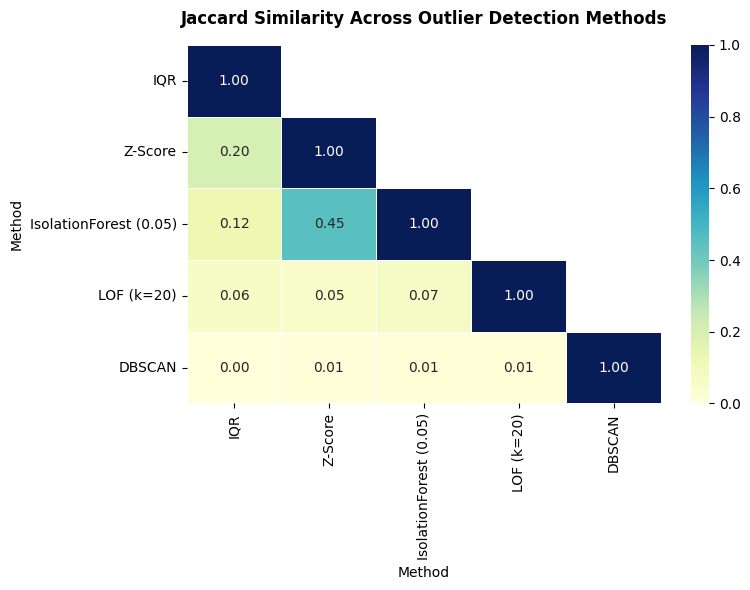

In [9]:
# Jaccard similarity function
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """
    Compute Jaccard similarity between two sets.
    J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not set_a and not set_b:
        return 1.0  # both sets empty → identical
    return len(set_a.intersection(set_b)) / len(set_a.union(set_b))


# Select representative methods for comparison
methods = [
    'IQR',
    'Z-Score',
    'IsolationForest (0.05)',
    'LOF (k=20)',
    'DBSCAN'
]
n_methods = len(methods)
jaccard_matrix = np.zeros((n_methods, n_methods))

# Compute pairwise Jaccard similarity matrix
for i, method_i in enumerate(methods):
    for j, method_j in enumerate(methods):
        jaccard_matrix[i, j] = jaccard_similarity(
            outlier_indices[method_i],
            outlier_indices[method_j]
        )

df_jaccard = pd.DataFrame(
    jaccard_matrix,
    index=methods,
    columns=methods
)

mask = np.triu(np.ones_like(df_jaccard, dtype=bool), k=1)
# Visualization: Jaccard similarity heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_jaccard, mask=mask, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5)

plt.title(
    "Jaccard Similarity Across Outlier Detection Methods",
    fontweight='bold', pad=15
)
plt.xlabel("Method")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

In [10]:
# Consensus outlier detection
all_detected_indices = []
for method in methods:
    all_detected_indices.extend(outlier_indices[method])
outlier_counter = Counter(all_detected_indices)

# Majority voting threshold
threshold = 3
consensus_outliers = [
    idx for idx, count in outlier_counter.items()
    if count >= threshold
]

n_consensus = len(consensus_outliers)
consensus_rate = (n_consensus / len(X)) * 100
print("\tCONSENSUS OUTLIER DETECTION (MAJORITY VOTING)")
print(f"Selected methods: {len(methods)}")
print(f"Voting threshold: >= {threshold} methods")
print(f"Consensus outliers: {n_consensus:,}")
print(f"Consensus rate: {consensus_rate:.2f}%")

	CONSENSUS OUTLIER DETECTION (MAJORITY VOTING)
Selected methods: 5
Voting threshold: >= 3 methods
Consensus outliers: 1,440
Consensus rate: 4.42%


Việc quan sát biểu đồ Heatmap Jaccard Similarity và kết quả bỏ phiếu đa số cung cấp cho nhóm cơ sở toán học vững chắc để gạn lọc ngoại lai:

**1. Jaccard Heatmap:**
* *Z-Score và Isolation Forest (0.05) có độ đồng thuận cao nhất ($Jaccard = 0.45$):* Cả hai thuật toán này đều có xu hướng nhắm vào các "Global Outliers" – những điểm nằm xa nhất so với trung tâm dữ liệu. Sự nhất trí này khẳng định những người có `capital.gain` hoặc `age` cực cao chắc chắn sẽ bị cả hai mô hình này tóm gọn.
* **LOF ($Jaccard \le 0.07$):** LOF gần như không có sự giao thoa với IQR, Z-Score hay iForest. Điều này hoàn toàn khớp với cơ sở lý thuyết: LOF tìm kiếm *Local Outliers*. Nó phát hiện ra những cá nhân có thuộc tính "bất thường so với những người giống họ" (ví dụ: một người trẻ tuổi, học vấn thấp nhưng lại có giờ làm việc và tài sản biến động lạ thường), chứ không đơn thuần là xét theo điểm cực đại toàn cục.

**2. Consensus Outliers:**
* Bằng cách áp dụng luật bỏ phiếu nghiêm ngặt (được cảnh báo bởi $\ge 3$ thuật toán), nhóm đã lọc ra được *1.440 quan sát (chiếm 4.42%)* là ngoại lai chắc chắn.
* *Giá trị của Ensemble:* Thay vì tin tưởng mù quáng vào IQR (phá hủy 41% dữ liệu) hay Z-Score (bị nhiễu bởi phân phối không chuẩn), cơ chế đồng thuận đã ép các thuật toán phải "kiểm chứng chéo" lẫn nhau. Con số $4.42\%$ là một tỷ lệ cực kỳ an toàn, hợp lý và đại diện cho những trường hợp sai số/cực đoan thực sự trong tập dữ liệu dân số $32.000$ mẫu.

### **4.4. Distributional Impact via KS Test**

Nếu loại bỏ trực tiếp tập ngoại lai đồng thuận này, liệu chúng ta có làm thay đổi hoàn toàn bản chất phân phối của dữ liệu gốc hay không? Nhóm sử dụng *Two-Sample Kolmogorov-Smirnov Test* để so sánh phân phối của cột `age` (đại diện) trước và sau khi xóa.

* $H_0$: Phân phối trước và sau khi xóa ngoại lai là hoàn toàn giống nhau.
* $H_1$: Xóa ngoại lai làm thay đổi/biến dạng phân phối dữ liệu (P-value $< 0.05$).

In [11]:
feature = 'age'
dist_before = X[feature].values
dist_after = X.drop(index=X.index[consensus_outliers])[feature].values

# Perform Kolmogorov–Smirnov test
ks_statistic, p_value = stats.ks_2samp(dist_before, dist_after)

print("\tKOLMOGOROV–SMIRNOV TEST (DISTRIBUTION SHIFT ANALYSIS)")
print(f"Feature evaluated: {feature}")
print(f"Sample size (before): {len(dist_before):,}")
print(f"Sample size (after): {len(dist_after):,}")
print(f"KS statistic (D): {ks_statistic:.4f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
print("\nInterpretation:")
if p_value < alpha:
    print("Reject the null hypothesis (H0).")
else:
    print("Fail to reject the null hypothesis (H0).")

	KOLMOGOROV–SMIRNOV TEST (DISTRIBUTION SHIFT ANALYSIS)
Feature evaluated: age
Sample size (before): 32,561
Sample size (after): 31,121
KS statistic (D): 0.0087
P-value: 1.8029e-01

Interpretation:
Fail to reject the null hypothesis (H0).


**Kết quả thực nghiệm:**
Với P-value đạt $0.1802$ (lớn hơn mức ý nghĩa $\alpha = 0.05$), ta *chấp nhận giả thuyết $H_0$*. Việc loại bỏ 1.440 quan sát không tạo ra sự khác biệt có ý nghĩa thống kê đối với hàm phân phối tích lũy (CDF) của tập dữ liệu.


### **4.5. Treatment Strategy: Majority Voting & Statistical Validation**

Dựa trên kết quả thực nghiệm từ ma trận Jaccard và kiểm định Kolmogorov-Smirnov (KS), nhóm đưa ra các nhận định và quyết định cuối cùng trong giai đoạn tiền xử lý ngoại lai:

1. **Sự mâu thuẫn về bản chất thuật toán:** Các thuật toán định chuẩn toàn cục (Z-Score, IQR) có sự đồng thuận với nhau, nhưng rất lệch pha với các thuật toán dựa trên cấu trúc hình học không gian (LOF). Điều này chứng minh định lý cơ bản: *"Ngoại lai trong thống kê đơn biến chưa chắc đã là ngoại lai trong không gian đa chiều"*.
2. **Ensemble Success:** Việc KS Test trả về kết quả an toàn (P-value $> 0.05$) là minh chứng toán học cho cơ chế "bỏ phiếu đa số" ($\ge 3$ thuật toán). Nhờ cơ chế này, nhóm đã chỉ nhắm mục tiêu vào 4.42% dữ liệu thực sự là "rác" (noise) hoặc lỗi hệ thống (ví dụ: người 90 tuổi làm việc 99 giờ/tuần), bảo vệ thành công cấu trúc phân phối gốc của Cục điều tra dân số.
3. **Treatment Strategy:** Dựa trên KS Test, nhóm quyết định *DROP* 1.440 quan sát ngoại lai đồng thuận này ra khỏi tập huấn luyện.
   * Hành động này sẽ giúp làm sạch bề mặt hao phí, giúp các mô hình Machine Learning ở giai đoạn sau (đặc biệt là Logistic Regression và SVM) hội tụ nhanh hơn và không bị nhiễu trọng số.
   * Riêng đối với các ngoại lai dạng "tầng lớp siêu giàu" (chỉ kích hoạt Z-score ở cột `capital.gain` nhưng không bị LOF/DBSCAN bắt), chúng đã được giữ lại an toàn do không đủ 3 phiếu bầu. Để xử lý mức độ chênh lệch của nhóm người giàu này, ở **mục 5**, nhóm sẽ áp dụng *Robust Scaling* hoặc *Quantile Transformer*.

In [12]:
df_adult_clean = df_adult.drop(index=consensus_outliers).reset_index(drop=True)
print(f"Dataset size after cleaning outliers: {df_adult_clean.shape}")

Dataset size after cleaning outliers: (31121, 15)


## **5. Data Scaling & Homoscedasticity**

### **5.1. Theoretical Foundation & Mathematical Formulas**

Để lựa chọn chiến lược chuẩn hóa phù hợp nhất cho từng đặc trưng, nhóm áp dụng và đối chiếu 4 phương pháp luận dựa trên cấu trúc phân phối của dữ liệu.

#### 1. Min-Max Scaling (Normalization)

* **Lý thuyết:** Phép biến đổi tuyến tính chiếu dữ liệu vào một khoảng cố định (thường là $[0, 1]$). Nó bảo toàn nguyên vẹn khoảng cách tương đối giữa các điểm dữ liệu. Ưu điểm lớn nhất là không làm thay đổi hình dáng phân phối gốc. Tuy nhiên, nó cực kỳ nhạy cảm với ngoại lai; một ngoại lai ở biên có thể nén toàn bộ inlier vào một không gian cực nhỏ, triệt tiêu phương sai của đặc trưng.
* **Toán học:** Chuyển đổi đặc trưng $X$ về khoảng tiêu chuẩn $[0, 1]$:
  $$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

#### 2. Z-score Standardization

* **Lý thuyết:** Chuẩn hóa dữ liệu xoay quanh giá trị trung bình là 0 và phương sai đơn vị là 1. Giả định dữ liệu tiệm cận phân phối Gaussian. Dữ liệu chuẩn hóa không bị giới hạn biên độ, phù hợp cho các thuật toán như SVM hay Logistic Regression. Dù chống chịu ngoại lai tốt hơn Min-Max, ngoại lai cực đoan vẫn có thể làm phình to độ lệch chuẩn $\sigma$ và kéo lệch tâm $\mu$.
* **Toán học:**
  $$Z = \frac{X - \mu}{\sigma}$$

#### 3. Robust Scaling

* **Lý thuyết:** Khi dữ liệu bị ô nhiễm bởi các phân phối đuôi dày (heavy-tailed) hoặc ngoại lai cực đoan, Robust Scaling sử dụng các công cụ ước lượng thống kê có "breakdown point" cao. Thuật toán dịch tâm bằng trung vị (breakdown point $\approx 50\%$) và co giãn bằng khoảng tứ phân vị IQR (điểm gãy $\approx 25\%$). Nhờ tập trung vào 50% dữ liệu vùng trung tâm, nó loại bỏ hoàn toàn sự nhiễu loạn từ hai phần đuôi ngoại lai.
* **Toán học:**
  $$X_{scaled} = \frac{X - Median(X)}{Q_3(X) - Q_1(X)}$$

#### 4. Quantile Transform (Non-Parametric Mapping)

* **Lý thuyết:** Đối với dữ liệu đa đỉnh hoặc vi phạm nghiêm trọng tính chuẩn/tuyến tính, Quantile Transform ánh xạ phi tuyến phân phối thực nghiệm của đặc trưng sang một phân phối đích.
  * **Uniform Output:** Dựa trên hàm phân phối tích lũy thực nghiệm (ECDF), trải đều các giá trị xuất hiện thường xuyên và thu hẹp khoảng cách của các ngoại lai.
  * **Normal Output:** Ánh xạ dữ liệu sang phân phối đều qua ECDF, sau đó áp dụng hàm Probit ($\Phi^{-1}$ - nghịch đảo của CDF chuẩn) để "ép" dữ liệu thành hình chuông hoàn hảo.
* **Toán học (Normal Output):**
  $$Y = \Phi^{-1}(F(X))$$

#### 5. Assessing Homoscedasticity: Levene’s Test

* **Lý thuyết:** Đồng nhất phương sai (Homoscedasticity) ngụ ý rằng phương sai của sai số không đổi trên mọi cấp độ của biến độc lập. Việc vi phạm (Heteroscedasticity) sẽ làm chệch các ước lượng thống kê. Nhóm sử dụng Levene's Test (phiên bản Brown-Forsythe dùng trung vị, rất mạnh mẽ trên dữ liệu không chuẩn) để kiểm tra sự đồng nhất phương sai của các biến số học giữa 2 nhóm giai cấp thu nhập (`<=50K` và `>50K`).
* **Toán học:**
  * Tính độ lệch tuyệt đối so với tâm nhóm $C_i$:
  $$Z_{ij} = |Y_{ij} - C_i|$$

  * Tính thống kê $W$ (Tỷ lệ phương sai giữa các nhóm trên phương sai nội bộ nhóm):
  $$
  W = \frac{N - k}{k - 1} \cdot
  \frac{\sum_{i=1}^{k} N_i \left(\bar{Z}_{i\cdot} - \bar{Z}_{\cdot\cdot}\right)^2}
  {\sum_{i=1}^{k} \sum_{j=1}^{N_i} \left(Z_{ij} - \bar{Z}_{i\cdot}\right)^2}
  $$
  
  * *Hệ quả:* Trị số $W$ tuân theo phân phối $F$. $P-value$ $< \alpha$ (thường là $0.05$) biểu thị bác bỏ $H_0$, xác nhận sự tồn tại của phương sai không đồng nhất.

### **5.2. Scaling Implementations**

Nhóm khởi tạo và áp dụng đồng loạt 5 chiến lược chuẩn hóa (bao gồm cả phân phối đích Uniform và Normal của Quantile Transformer) lên *toàn bộ 6 biến số học*. Quá trình này tạo ra các không gian đặc trưng song song để chuẩn bị cho quá trình đánh giá định lượng và trực quan.

In [13]:
# Define numerical features and target variable
num_cols = [
    'age', 'fnlwgt', 'education.num',
    'capital.gain', 'capital.loss', 'hours.per.week'
]
X_num = df_adult_clean[num_cols].copy()
y = df_adult_clean['income'].copy()

# Initialize scaling methods
scalers = {
    'Original': None,
    'Min-Max Scaling': MinMaxScaler(),
    'Standard Scaling (Z-score)': StandardScaler(),
    'Robust Scaling (IQR)': RobustScaler(),
    'Quantile (Uniform)': QuantileTransformer(
        output_distribution='uniform',
        random_state=42
    ),
    'Quantile (Normal)': QuantileTransformer(
        output_distribution='normal',
        random_state=42
    )
}

# Apply transformations
scaled_datasets = {}
for name, scaler in scalers.items():
    if scaler is None:
        scaled_datasets[name] = X_num.copy()
    else:
        transformed = scaler.fit_transform(X_num)
        scaled_datasets[name] = pd.DataFrame(
            transformed,
            columns=num_cols,
            index=X_num.index
        )

print("\tFEATURE SCALING COMPLETED")
print(f"Number of samples: {X_num.shape[0]:,}")
print(f"Number of features: {X_num.shape[1]}")
print(f"Scaling methods applied: {len(scalers)}\n")
print("Available transformed datasets:")
for name in scaled_datasets.keys():
    print(f" - {name}")

	FEATURE SCALING COMPLETED
Number of samples: 31,121
Number of features: 6
Scaling methods applied: 6

Available transformed datasets:
 - Original
 - Min-Max Scaling
 - Standard Scaling (Z-score)
 - Robust Scaling (IQR)
 - Quantile (Uniform)
 - Quantile (Normal)


In [14]:
# Example preview
print("\nPreview: Standard Scaling (first 5 rows)")
display(scaled_datasets['Standard Scaling (Z-score)'].head())


Preview: Standard Scaling (first 5 rows)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
0,0.205869,-0.179660,-0.417302,-0.236924,9.155375,-0.017807
1,-0.317500,-0.077409,-0.019250,-0.236924,9.155375,-0.017807
2,0.504938,0.179612,0.776855,-0.236924,8.733265,-0.017807
3,-0.616568,-0.390882,-0.417302,-0.236924,8.635199,-0.017807
4,-0.317500,0.109078,-0.019250,-0.236924,8.635199,-0.017807


### **5.3 Homoscedasticity Assessment**

Nhóm áp dụng *Levene's Test (Brown-Forsythe variant, sử dụng Median)* quét qua toàn bộ 6 thuộc tính định lượng.
* $H_0$: Phương sai của biến số giữa hai nhóm thu nhập (`<=50K` và `>50K`) là bằng nhau (Homoscedasticity).
* $H_1$: Có sự khác biệt ý nghĩa về phương sai (Heteroscedasticity).

Mục tiêu là kiểm tra xem phép chuẩn hóa nào giúp duy trì, hoặc ép cưỡng bức được sự đồng nhất phương sai (đạt P-value $> 0.05$).

In [15]:
levene_results = []

# Perform Levene's test for each feature and scaling method
for feature in num_cols:
    for method_name, df_scaled in scaled_datasets.items():

        # Split data into two groups based on target label
        group_low = df_scaled.loc[y == '<=50K', feature].dropna()
        group_high = df_scaled.loc[y == '>50K', feature].dropna()

        # Apply Levene's test (median-centered for robustness against outliers)
        stat, p_value = stats.levene(group_low, group_high, center='median')

        # Store results
        levene_results.append({
            'Feature': feature,
            'Scaling Method': method_name,
            'P-value': p_value
        })

# Convert results to pivot table
df_levene = (
    pd.DataFrame(levene_results)
    .pivot(index='Feature', columns='Scaling Method', values='P-value')
    .sort_index()
)

print("\tLEVENE'S TEST RESULTS (HOMOGENEITY OF VARIANCE)")
print("Hypothesis:")
print(" - H0: Equal variances across income groups")
print(" - H1: Unequal variances\n")

display(
    df_levene.style
    .format("{:.4f}")
    .highlight_between(
        left=0,
        right=0.05,
        color='#ffcccc'
    )
)

	LEVENE'S TEST RESULTS (HOMOGENEITY OF VARIANCE)
Hypothesis:
 - H0: Equal variances across income groups
 - H1: Unequal variances



Scaling Method,Min-Max Scaling,Original,Quantile (Normal),Quantile (Uniform),Robust Scaling (IQR),Standard Scaling (Z-score)
Feature,,,,,,
age,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
capital.gain,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
capital.loss,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
education.num,0.0000,0.0000,0.0000,0.0009,0.0000,0.0000
fnlwgt,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
hours.per.week,0.8298,0.8298,0.0000,0.0000,0.8298,0.8298


In [16]:
summary = (df_levene >= 0.05).sum().sort_values(ascending=False)
print("\nNumber of features satisfying homoscedasticity (p >= 0.05):")
print(summary)


Number of features satisfying homoscedasticity (p >= 0.05):
Scaling Method
Min-Max Scaling               1
Original                      1
Standard Scaling (Z-score)    1
Robust Scaling (IQR)          1
Quantile (Uniform)            0
Quantile (Normal)             0
dtype: int64


Dựa trên bảng kết quả kiểm định Levene, nhóm rút ra 3 luận điểm quan trọng về cấu trúc phương sai của dữ liệu:

**1. Inherent Heteroscedasticity:**
Đối với 5/6 biến số học (`age`, `capital.gain`, `capital.loss`, `education.num`, `fnlwgt`), chỉ số p-value đều bằng 0.0000 (nhỏ hơn rất nhiều mức ý nghĩa 0.05) trên mọi phương pháp chuẩn hóa. Ta *bác bỏ giả thuyết H0*. Điều này phản ánh một thực tế xã hội: Phương sai của hai tầng lớp thu nhập là hoàn toàn khác biệt (ví dụ: nhóm giàu có sự biến thiên cực lớn về tài sản đầu tư, trong khi nhóm nghèo gần như bằng 0). Các phép chuẩn hóa tuyến tính (Min-Max, Z-Score) chỉ dịch chuyển hệ trục tọa độ, hoàn toàn không thể làm thay đổi bản chất bất đồng nhất này.

**2. `hours.per.week`:**
Đây là thuộc tính duy nhất vượt qua kiểm định (p-value = 0.8298 > 0.05) và *chấp nhận H0* ở dữ liệu gốc. Con số này cho thấy: Sự phân tán về thời gian làm việc của cả người giàu lẫn người nghèo là tương đương nhau (dao động quanh mốc tiêu chuẩn 40 giờ/tuần). Các phép chuẩn hóa tuyến tính và Robust Scaling đã bảo toàn thành công cấu trúc phương sai ổn định này.

**3. Quantile Distortion:**
Một điểm cực kỳ đáng lưu tâm là *Quantile Transform* (cả Uniform và Normal) đã phá vỡ hoàn toàn tính đồng nhất phương sai của biến `hours.per.week` (kéo p-value từ 0.8298 tụt xuống 0.0000). Phép biến đổi phi tuyến này ép cưỡng bức dữ liệu theo thứ hạng, vô tình làm bóp méo cấu trúc phân bố tự nhiên và tạo ra sự chênh lệch phương sai giả giữa hai nhóm.

**Strategic Conclusion:** Thay vì cố gắng đồng nhất phương sai, nhóm sẽ chọn các bộ chuẩn hóa giúp tối ưu bề mặt hao phí (Loss Landscape) cho mô hình Học máy: *kết hợp Min-Max (cho các biến có phương sai ổn định như `hours.per.week`) và Robust Scaling (để kiềm chế các biến lệch cực đoan như `capital.gain`).*

### **5.4 Visualizing Distributional Impact**

Để minh họa trực quan sự thay đổi trong cấu trúc dữ liệu dưới tác động của các bộ chuẩn hóa, nhóm sử dụng biểu đồ Violin Plot trên thuộc tính `capital.gain`. Biểu đồ này giúp quan sát đồng thời cả các chỉ số tứ phân vị (giống Boxplot) và hình dáng hàm mật độ xác suất KDE (Kernel Density Estimation).

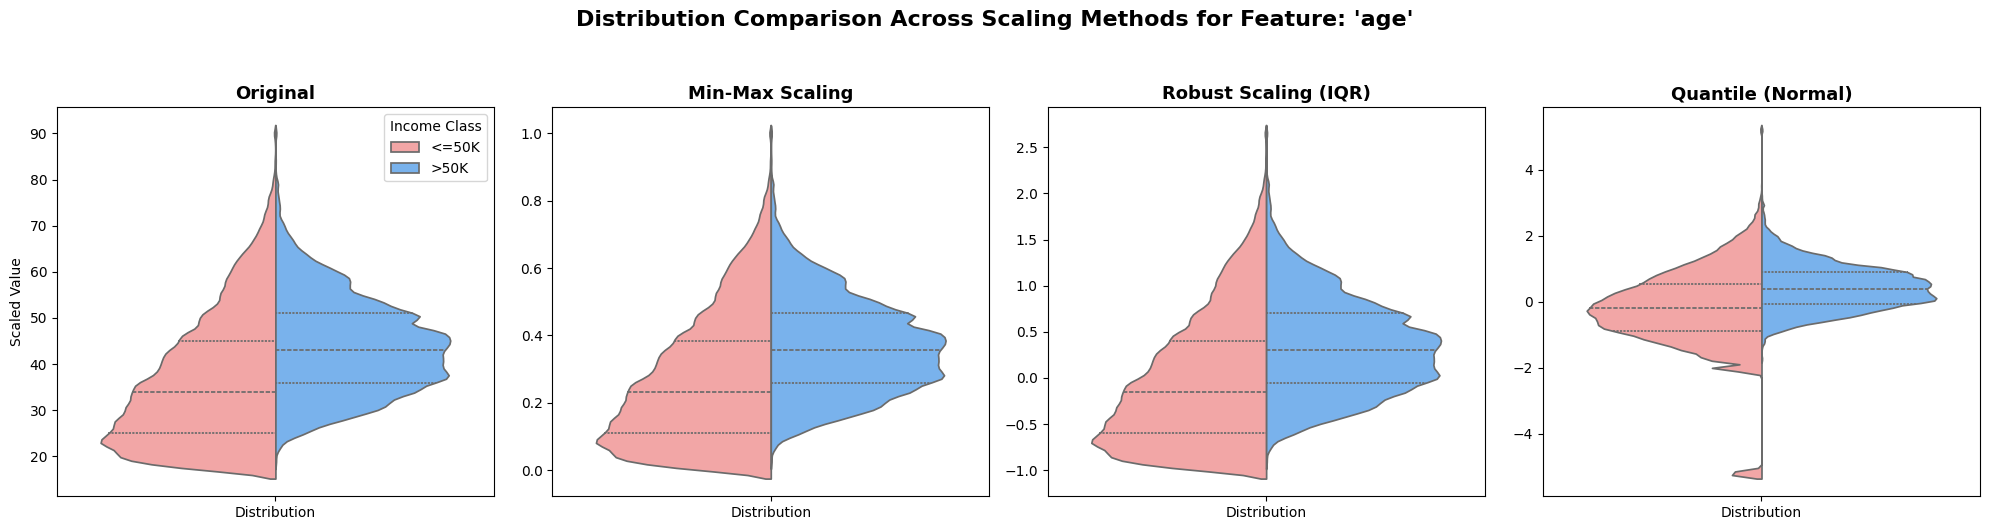

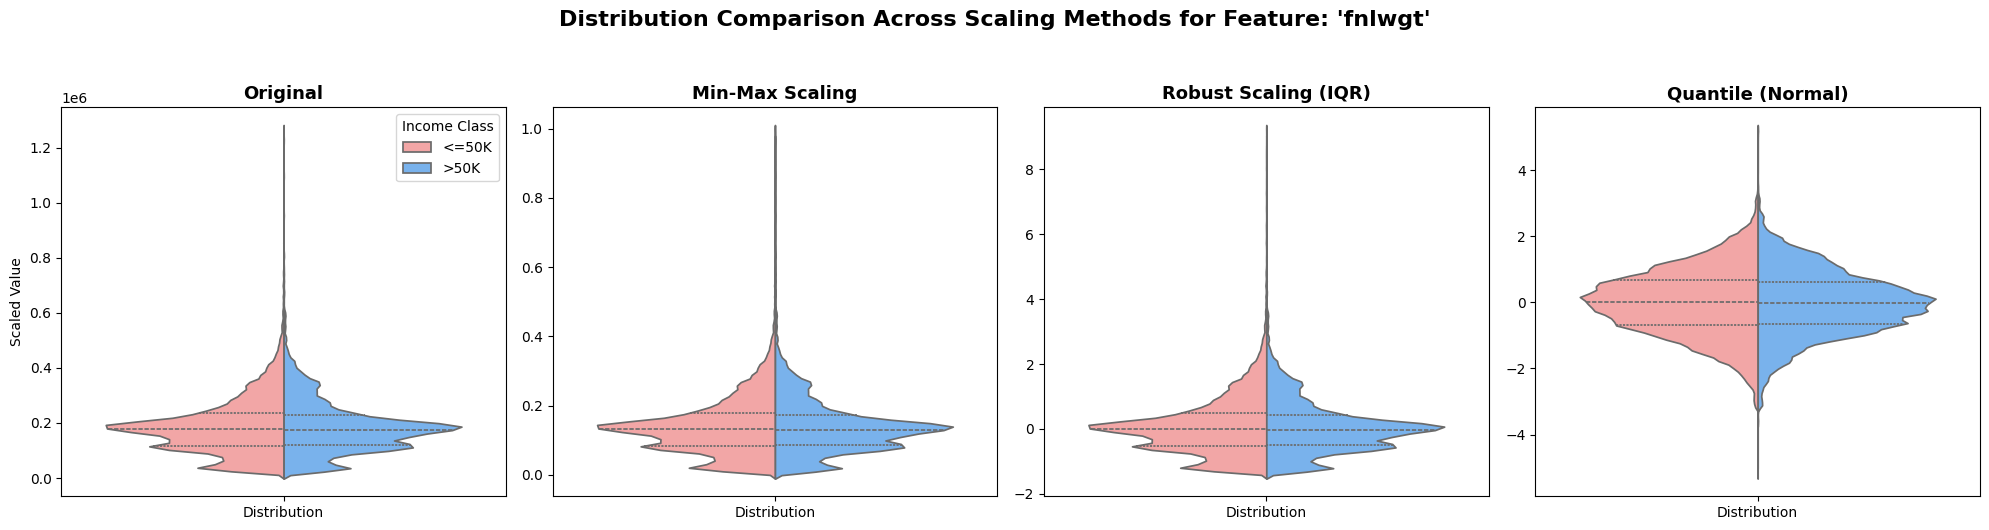

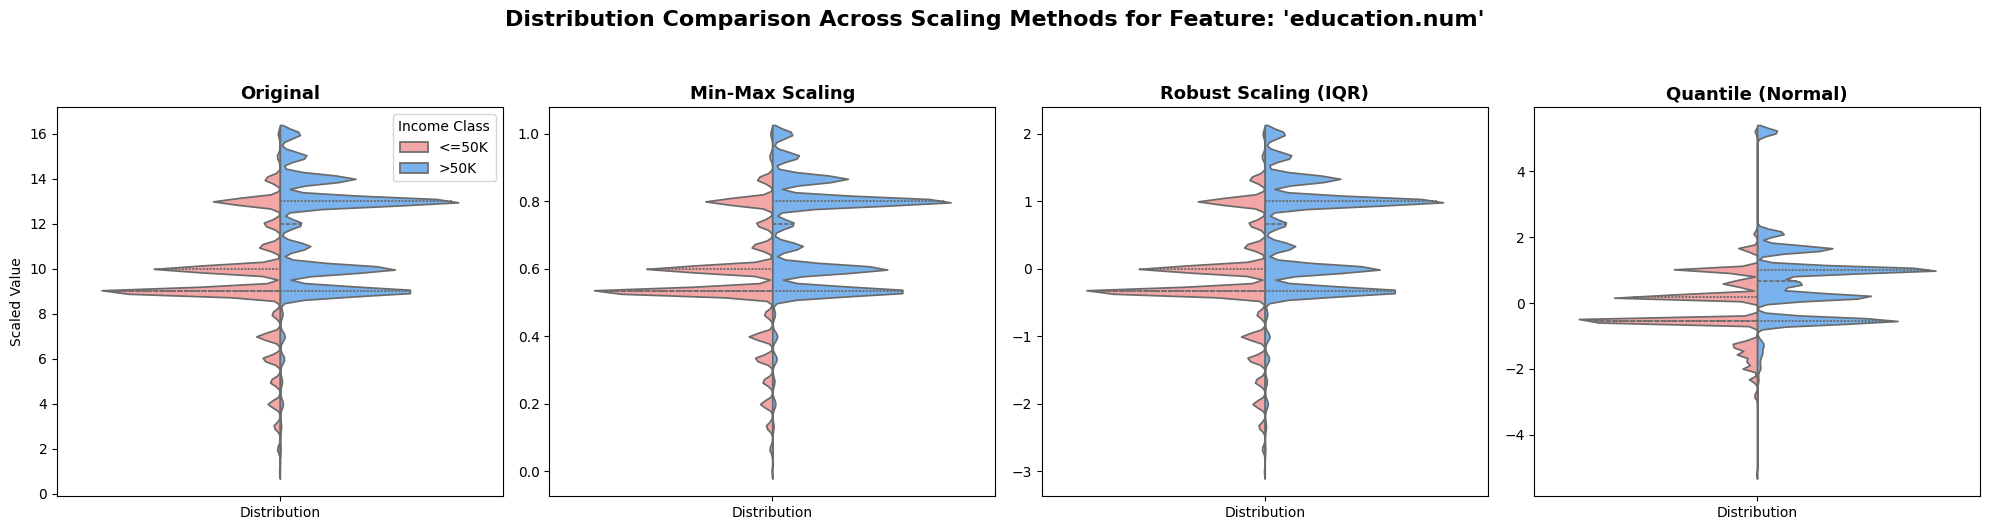

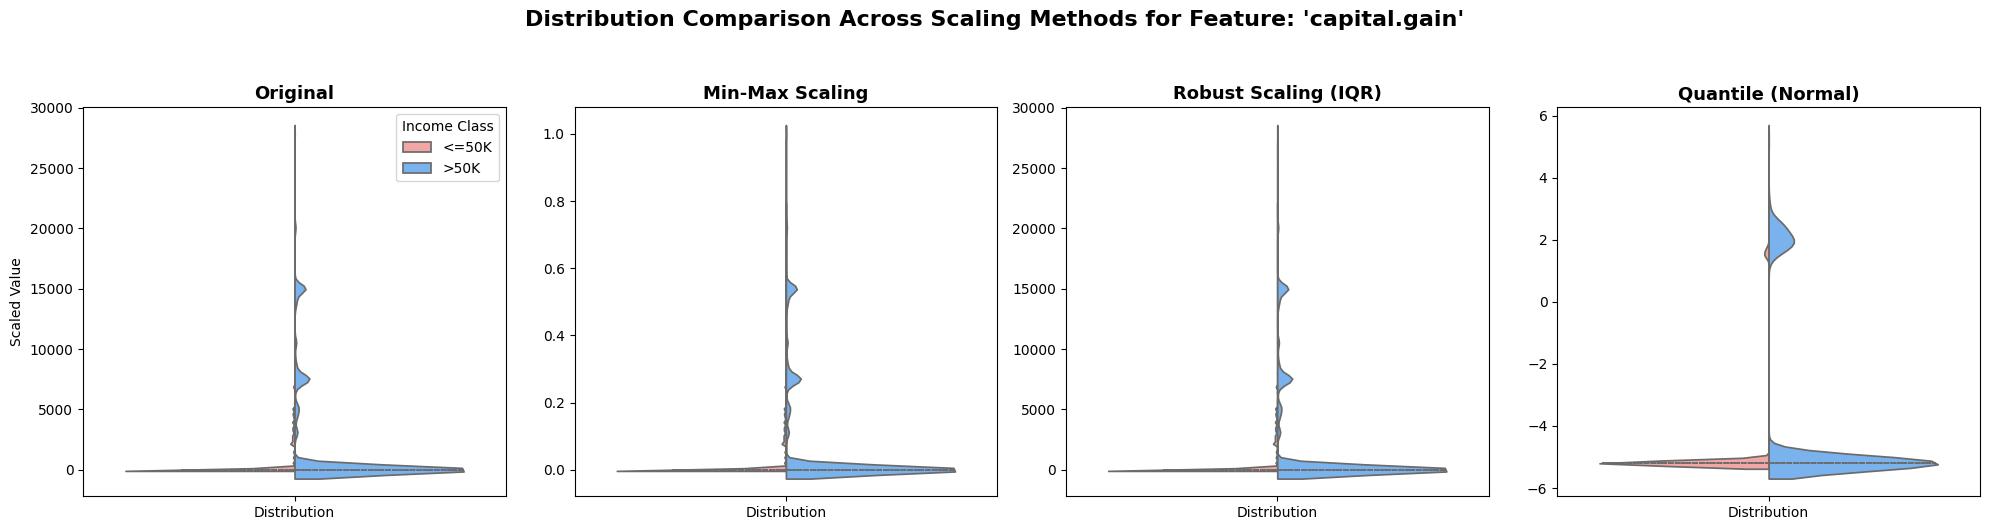

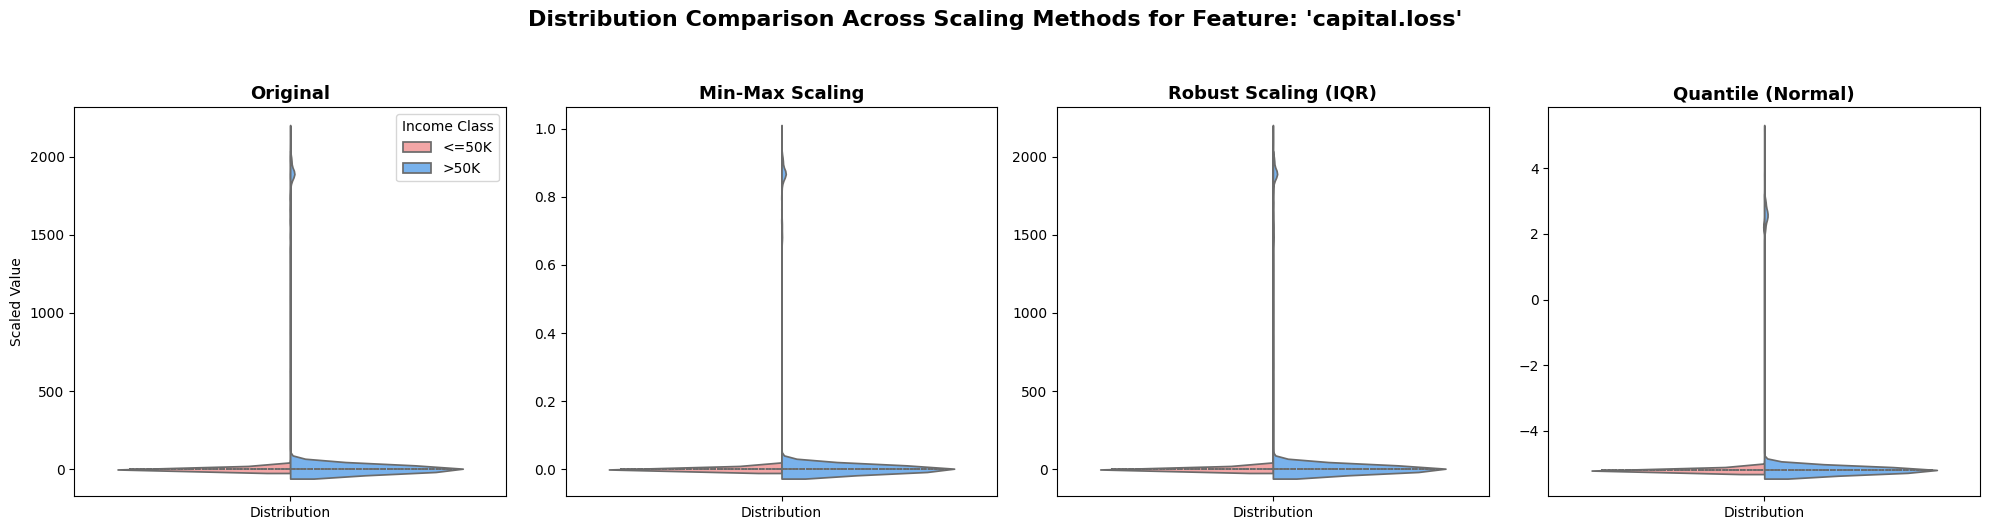

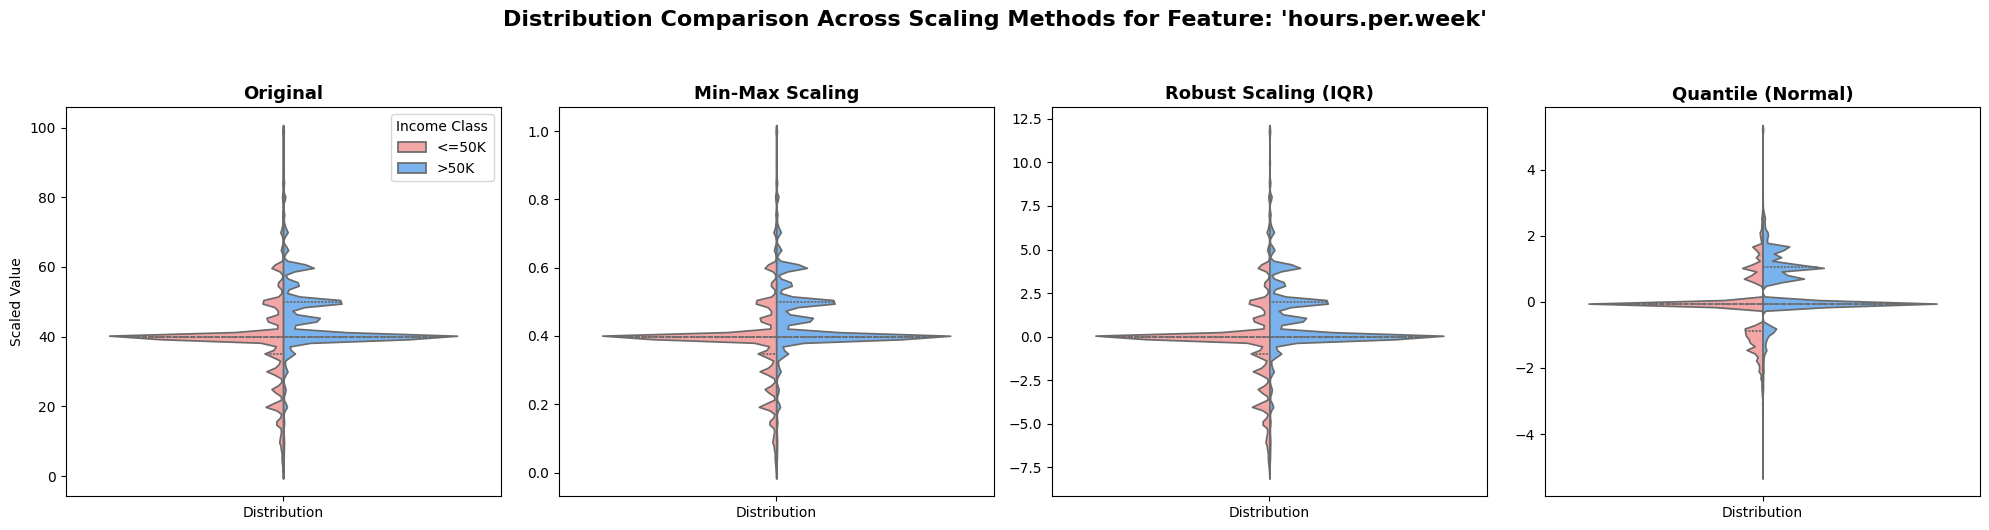

In [17]:
# Select representative scaling methods
methods_to_plot = [
    'Original',
    'Min-Max Scaling',
    'Robust Scaling (IQR)',
    'Quantile (Normal)'
]

# Visualization loop for all numerical features
for feature in num_cols:
    # Create subplot grid (one column per scaling method)
    fig, axes = plt.subplots(
        1,
        len(methods_to_plot),
        figsize=(20, 5),
        sharey=False
    )
    for i, method in enumerate(methods_to_plot):

        # Extract scaled data
        data_scaled = scaled_datasets[method][feature].dropna()
        y_aligned = y.loc[data_scaled.index]

        # Prepare plotting DataFrame
        df_plot = pd.DataFrame({
            'Scaled Value': data_scaled.values,
            'Income Class': y_aligned.values,
            'Group': 'Distribution'
        })

        # Plot split violin
        sns.violinplot(
            data=df_plot,
            x='Group',
            y='Scaled Value',
            hue='Income Class',
            split=True,
            inner='quartile',
            density_norm='area',
            bw_adjust=0.5,
            palette=['#FF9999', '#66B2FF'],
            ax=axes[i],
            legend=(i == 0)
        )
        axes[i].set_title(
            f"{method}",
            fontsize=13,
            fontweight='bold'
        )
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Scaled Value" if i == 0 else "")
    plt.suptitle(
        f"Distribution Comparison Across Scaling Methods for Feature: '{feature}'",
        fontsize=16,
        fontweight='bold',
        y=1.05
    )
    plt.tight_layout()
    plt.show()

### **5.6 Critical Review and Final Scaling Strategy**

Sau khi đối chiếu kết quả kiểm định Levene's Test và quan sát sự biến thiên hình thái qua 6 biểu đồ Split Violin, nhóm đánh giá tác động của các bộ chuẩn hóa lên từng nhóm đặc trưng như sau:

**1. Nhóm biến có ranh giới xã hội rời rạc (`hours.per.week`, `education.num`):**
* **Hiện tượng:** Biểu đồ Original cho thấy các "đỉnh nhọn" rất rõ nét tại các giá trị thường gặp trong xã hội, ví dụ: 40 giờ làm việc mỗi tuần hoặc 13 năm học (tương đương bằng cử nhân). Điều này cho thấy dữ liệu tập trung nhiều ở những mốc thời gian này.
* **Quantile (Normal):** Phép biến đổi Quantile (thường được gọi là biến đổi "Normal") là một phép biến đổi phi tuyến. Nó đã làm "phẳng" hoàn toàn các đỉnh nhọn này, biến biểu đồ thành một hình chuông (phân phối Gaussian). Về mặt toán học, nó tạo ra phân phối chuẩn; nhưng về mặt nghiệp vụ, nó loại bỏ hoàn toàn thông tin xã hội học quan trọng có trong dữ liệu gốc. Các mốc như 40 giờ/tuần hoặc 13 năm học không còn được thể hiện rõ ràng nữa. Hơn nữa, như Levene's Test đã chỉ ra, nó còn phá vỡ tính đồng nhất phương sai của biến `hours.per.week`. Điều này có nghĩa là phương sai (mức độ phân tán) của dữ liệu trong các nhóm khác nhau trở nên không đồng đều, ảnh hưởng đến một số phân tích thống kê.


**2. Nhóm biến phân phối lệch cực đoan (`capital.gain`, `capital.loss`):**
* **Hiện tượng:** Đây là các biến Zero-inflated (phần lớn dân số có giá trị bằng 0).
* **Min-Max:** Khi áp dụng Min-Max scaling, biểu đồ Violin cho thấy 99% dữ liệu bị "nén" thành một đường thẳng mỏng ở giá trị 0. Điều này xảy ra vì một số ít cá nhân có giá trị rất lớn (siêu giàu) làm cho phạm vi giá trị rất rộng. Kết quả là, phương sai (variance) của phần lớn dữ liệu bị triệt tiêu, làm giảm hiệu quả học máy.
* **Robust Scaler:** Thuật toán Robust Scaler giữ giá trị 0 ở vị trí trung tâm (do giá trị trung vị (Median) bằng 0). Nó cũng giúp giảm ảnh hưởng của các giá trị ngoại lai (outliers) mà không làm mất đi cấu trúc đuôi dài (heavy-tail) của phân phối.

**3. Nhóm biến phân phối tự nhiên (`age`, `fnlwgt`):**
* Với biến `age` (tuổi), các biểu đồ Original (gốc), Min-Max (tỉ lệ về [0,1]), và Robust (loại bỏ outlier) cho thấy sự khác biệt rõ ràng giữa các thế hệ: Nhóm có thu nhập $\le50K$ (màu đỏ) tập trung nhiều ở độ tuổi thanh niên 20-30, trong khi nhóm có thu nhập $>50K$ (màu xanh) đạt đỉnh muộn hơn, ở độ tuổi trung niên 40-50. Cả phương pháp Min-Max và Robust đều giữ lại rất tốt câu chuyện "tích lũy tài sản theo thời gian" này.

**SCALING STRATEGY: HYBRID SCALING**

1. **Sử dụng MinMaxScaler:** Cho các biến mang ý nghĩa mốc thời gian/giáo dục (`age`, `education.num`, `hours.per.week`). Việc này giúp dưa dữ liệu về khoảng [0, 1] để tối ưu hóa thuật toán, đồng thời vẫn giữ nguyên các điểm đặc biệt (ví dụ: mốc 40 giờ làm việc) và khoảng cách tương đối giữa các dữ liệu.
2. **Sử dụng RobustScaler:** Bắt buộc áp dụng cho các biến tài chính nhạy cảm với ngoại lai (`capital.gain`, `capital.loss`) và `fnlwgt`. Sử dụng khoảng tứ phân vị (IQR) giúp giảm ảnh hưởng của các giá trị ngoại lai, đặc biệt là của những người có thu nhập rất cao, mà không làm sai lệch thực tế là phần lớn dân số không có thu nhập từ đầu tư.
3. **Loại bỏ QuantileTransformer:** Mặc dù tạo ra phân phối chuẩn đẹp, nhưng việc làm méo cấu trúc dữ liệu rời rạc và làm sai lệch ý nghĩa xã hội học khiến nó không phù hợp với bài toán phân loại nhân khẩu học Adult Census.

In [18]:
minmax_cols = ['age', 'education.num', 'hours.per.week']
robust_cols = ['capital.gain', 'capital.loss', 'fnlwgt']
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
df_adult_clean[minmax_cols] = minmax_scaler.fit_transform(df_adult_clean[minmax_cols])
df_adult_clean[robust_cols] = robust_scaler.fit_transform(df_adult_clean[robust_cols])


print("\tDESCRIBED STATISTICS AFTER STANDARDIZATION")
display(df_adult_clean[minmax_cols + robust_cols].describe().round(3))

	DESCRIBED STATISTICS AFTER STANDARDIZATION


,age,education.num,hours.per.week,capital.gain,capital.loss,fnlwgt
count,31121.000,31121.000,31121.000,31121.000,31121.000,31121.000
mean,0.291,0.603,0.400,541.027,31.737,0.088
std,0.183,0.167,0.120,2283.587,234.539,0.871
min,0.000,0.000,0.000,0.000,0.000,-1.408
25%,0.137,0.533,0.398,0.000,0.000,-0.511
50%,0.274,0.600,0.398,0.000,0.000,0.000
75%,0.411,0.733,0.449,0.000,0.000,0.489
max,1.000,1.000,1.000,27828.000,2179.000,9.241


## **6. Multivariate Correlation & Multicollinearity Analysis**



## 4. Mã hóa biến phân loại nâng cao (Advanced Categorical Encoding)
*Mục tiêu: Chuyển đổi dữ liệu chuỗi thành số học mà không làm bùng nổ số chiều (Curse of Dimensionality).*
* **4.1 Base Encodings:** One-Hot Encoding (cho biến ít giá trị như `sex`, `race`) và Ordinal Encoding.
* **4.2 High-Cardinality Encodings (Áp dụng cho `native.country`, `occupation`):**
    * **Target Encoding (Mean Encoding):** Bắt buộc phải sử dụng Cross-validation (như `CategoryEncoders` library) hoặc thêm Gaussian Noise để chống Target Leakage (học vẹt nhãn).
    * **Binary Encoding:** Giảm chiều không gian cho biến có số lượng hạng mục $>20$ bằng biểu diễn nhị phân.
    * **Frequency Encoding:** Thay thế tên hạng mục bằng tần suất xuất hiện của nó.
* **4.3 Kiểm tra Đa cộng tuyến phát sinh (VIF Analysis):** Tính toán Hệ số phóng đại phương sai (Variance Inflation Factor - VIF) cho tập dữ liệu sau khi mã hóa. Nhận xét xem Target Encoding có vô tình tạo ra sự phụ thuộc tuyến tính mới nào không.

### **6.1 Theoretical Foundation: Correlation Metrics**

### **6.2 Bivariate Analysis & Heatmap Visualization**

### **6.3 Multicollinearity Detection & Critical Analysis**

### **6.4 Proposed Treatments for Multicollinearity**

---